# FinTech İşlem Verisi — SQL & pandas EDA

**Amaç:** Finansal işlem verisini SQL ve pandas ile analiz etmek  
**Araçlar:** PostgreSQL, pandas, matplotlib, sqlalchemy  
**Tarih:** Haziran 2026

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

engine = create_engine(
    "postgresql://postgres@localhost:5432/fintech_db"
)

# Test
df = pd.read_sql("SELECT version()", engine)
print(df)

                                             version
0  PostgreSQL 18.4 on x86_64-windows, compiled by...


In [2]:
# Tabloyu oluştur
from sqlalchemy import text

with engine.connect() as conn:
    conn.execute(text("""
        DROP TABLE IF EXISTS islemler;
        CREATE TABLE islemler (
            islem_id   INTEGER,
            musteri_id INTEGER,
            tutar      REAL,
            kategori   TEXT,
            durum      TEXT
        );
    """))
    conn.execute(text("""
        INSERT INTO islemler VALUES
            (1, 1, 1500, 'Alışveriş', 'onaylı'),
            (2, 2, 320,  'Fatura',    'onaylı'),
            (3, 3, 8900, 'Transfer',  'beklemede'),
            (4, 1, 450,  'Fatura',    'onaylı'),
            (5, 4, 12000,'Transfer',  'iptal'),
            (6, 2, 75,   'Alışveriş', 'onaylı'),
            (7, 3, 2200, 'Alışveriş', 'onaylı'),
            (8, 4, 580,  'Fatura',    'onaylı'),
            (9, 1, 3300, 'Transfer',  'onaylı'),
            (10,4, 990,  'Alışveriş', 'beklemede');
    """))
    conn.commit()

print("Tablo oluşturuldu!")

Tablo oluşturuldu!


In [3]:
# Veriyi yükle
df = pd.read_sql("SELECT * FROM islemler", engine)

print("Satır sayısı:", len(df))
print("\nSütunlar:", df.columns.tolist())
print("\nİlk 5 satır:")
df.head()

Satır sayısı: 10

Sütunlar: ['islem_id', 'musteri_id', 'tutar', 'kategori', 'durum']

İlk 5 satır:


,islem_id,musteri_id,tutar,kategori,durum
0,1,1,1500.0,Alışveriş,onaylı
1,2,2,320.0,Fatura,onaylı
2,3,3,8900.0,Transfer,beklemede
3,4,1,450.0,Fatura,onaylı
4,5,4,12000.0,Transfer,iptal


In [4]:
# Kategori bazında analiz
query = """
    SELECT 
        kategori,
        COUNT(*)      AS islem_sayisi,
        SUM(tutar)    AS toplam_tutar,
        AVG(tutar)    AS ort_tutar
    FROM islemler
    GROUP BY kategori
    ORDER BY toplam_tutar DESC
"""

kategori_df = pd.read_sql(query, engine)
kategori_df

,kategori,islem_sayisi,toplam_tutar,ort_tutar
0,Transfer,3,24200.0,8066.666667
1,Alışveriş,4,4765.0,1191.250000
2,Fatura,3,1350.0,450.000000


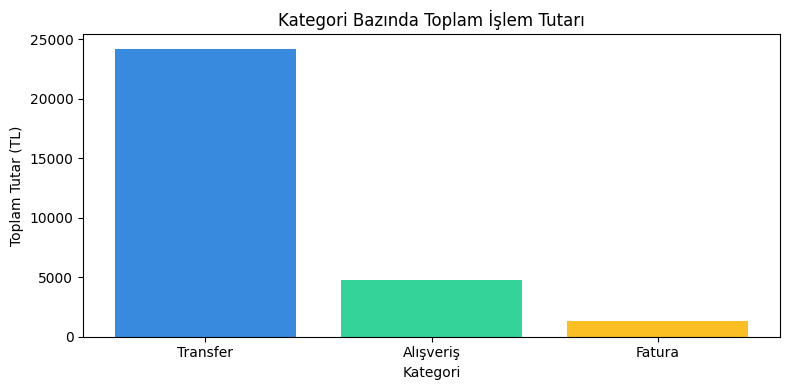

In [5]:
# Kategori bazında tutar grafiği
plt.figure(figsize=(8, 4))
plt.bar(kategori_df['kategori'], kategori_df['toplam_tutar'],
        color=['#378ADD', '#34d399', '#fbbf24'])
plt.title('Kategori Bazında Toplam İşlem Tutarı')
plt.xlabel('Kategori')
plt.ylabel('Toplam Tutar (TL)')
plt.tight_layout()
plt.savefig('kategori_analiz.png')
plt.show()
